In [14]:
%pip install --upgrade -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import iqr
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

In [16]:
# Load the dataset
file_path = "data/processed/medicare_acs_analysis.csv"
analysis_df = pd.read_csv(file_path, dtype={"fips": str}) # read fips as a string so the leading zeros are preserved

In [17]:
analysis_df.dtypes

fips                               str
county_name                        str
avg_annual_om_beneficiaries    float64
avg_age                        float64
female_pct                     float64
male_pct                       float64
inpatient_stays_per_1000       float64
outpatient_visits_per_1000     float64
er_visits_per_1000             float64
median_household_income        float64
poverty_rate                   float64
bachelors_or_higher_pct        float64
dtype: object

In [18]:
utilization_cols = ['inpatient_stays_per_1000', 'outpatient_visits_per_1000', 'er_visits_per_1000']

In [19]:
# Check for missing values
analysis_df.isnull().sum()

fips                           0
county_name                    0
avg_annual_om_beneficiaries    1
avg_age                        1
female_pct                     3
male_pct                       3
inpatient_stays_per_1000       4
outpatient_visits_per_1000     2
er_visits_per_1000             3
median_household_income        1
poverty_rate                   0
bachelors_or_higher_pct        0
dtype: int64

In [20]:
# Drop rows with missing values
analysis_df = analysis_df.dropna()

* include justification for dropping missing values in data cleaning section of report (pointing to this part of the notebook)

## Descriptive Analysis

To analyze how inpatient, outpatient, and emergency department utilization rates vary geographically, we computed summary statistics (i.e., mean, median, interquartile range, standard deviation) and generate county-level choropleth maps across all three care settings. Through this, we expected to learn the baseline distribution, dispersion, and spatial clustering of healthcare utilization per 1,000 beneficiaries across U.S. counties.

In [21]:
summary_stats = analysis_df[utilization_cols].describe()
summary_stats

,inpatient_stays_per_1000,outpatient_visits_per_1000,er_visits_per_1000
count,3129.000000,3129.000000,3129.000000
mean,215.479712,5451.299407,588.512166
std,41.105920,2206.735537,107.848809
min,91.377316,915.341543,49.339544
25%,187.500004,3710.753226,522.361478
50%,215.258374,5122.816159,589.200674
75%,241.218527,6844.663557,657.162140
max,496.212128,13988.443967,1149.651062


In [22]:
for col in utilization_cols:
  print(col)
  print(f'-  Mean: {summary_stats.loc['mean', col]}')
  print(f'-  Median: {summary_stats.loc['50%', col]  }')
  print(f'-  Std Dev: {summary_stats.loc['std', col]}')
  print(f'-  IQR: {summary_stats.loc['75%', col] - summary_stats.loc['25%', col]}\n')

inpatient_stays_per_1000
-  Mean: 215.47971246132215
-  Median: 215.25837351212343
-  Std Dev: 41.10591996171189
-  IQR: 53.71852294597255

outpatient_visits_per_1000
-  Mean: 5451.299406859644
-  Median: 5122.8161585136895
-  Std Dev: 2206.735537406361
-  IQR: 3133.910331311811

er_visits_per_1000
-  Mean: 588.5121662634278
-  Median: 589.2006744875562
-  Std Dev: 107.84880897944801
-  IQR: 134.80066182709982



In [23]:
# Generate a county-level choropleth map for each care setting
titles = {'inpatient_stays_per_1000': 'Inpatient Stays per 1,000 Beneficiaries',
          'outpatient_visits_per_1000': 'Outpatient Visits per 1,000 Beneficiaries',
          'er_visits_per_1000': 'Emergency Department Visits per 1,000 Beneficiaries'}
for col in utilization_cols:
    fig = px.choropleth(
        analysis_df,
        geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
        locations='fips',
        color=col,
        color_continuous_scale="Magma_r", # (color-blind friendly and intuitive)
        scope="usa",
        title=f"County-Level Choropleth Map of {titles[col]}"
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_traces(marker_line_width=0.2, marker_line_color="rgba(255, 255, 255, 0.5)")  # lighten border lines 

    fig.show()

## Correlation Analysis

We calculated Pearson and Spearman rank correlation coefficients to quantify the linear and monotonic relationships between county-level socioeconomic factors (e.g., median household income, poverty rate, educational attainment) and healthcare utilization rates.

Pearson correlations quantify linear associations, while Spearman correlations assess monotonic associations that are less sensitive to skew and outliers. Each coefficient uses pairwise-complete observations for the relevant socioeconomic, demographic, and utilization variables.

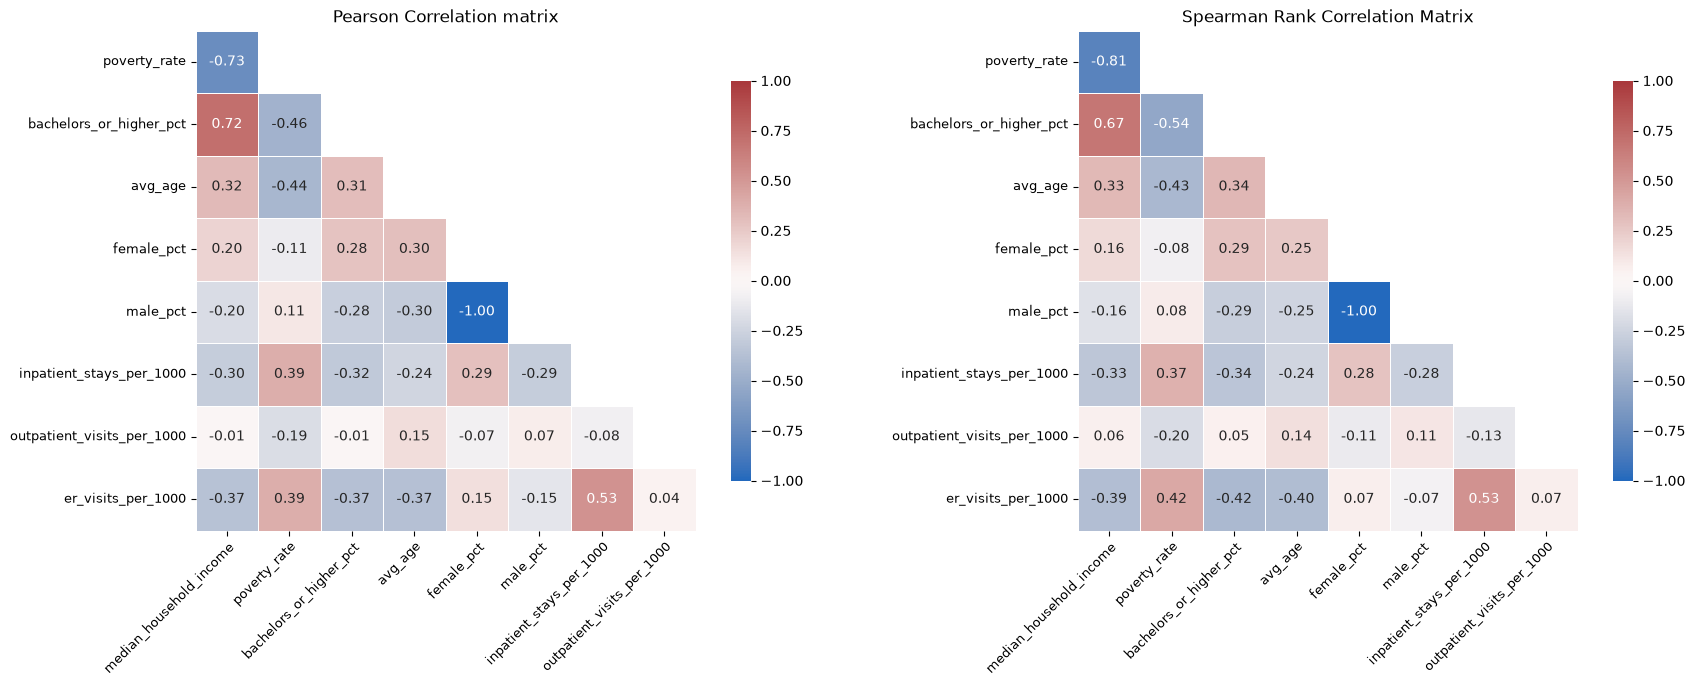

In [24]:
socioeconomic_cols = ["median_household_income", "poverty_rate", "bachelors_or_higher_pct"]
demographic_cols = ["avg_age", "female_pct", "male_pct"] # (age & biological sex)
correlation_data = analysis_df[socioeconomic_cols + demographic_cols + utilization_cols]

pearson_corr = correlation_data.corr(method="pearson")
spearman_corr = correlation_data.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, matrix, title in zip(
    axes,
    (pearson_corr, spearman_corr),
    ("Pearson Correlation matrix", "Spearman Rank Correlation Matrix"),
):
    mask = np.triu(np.ones_like(matrix, dtype=bool))
    matrix_sliced = matrix.iloc[1:, :-1]
    mask_sliced = mask[1:, :-1]
    sns.heatmap(
        matrix_sliced,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax,
        mask=mask_sliced
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    # Fetch the generated tick objects and explicitly change their anchor behavior
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        rotation=45, 
        ha="right",              # Right edge alignments
        rotation_mode="anchor",  # Forces the rotation to pivot around the right edge anchor point
        fontsize=9
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Predictive Analysis via Supervised Learning

We trained tree-based ensemble models (i.e., Random Forest, XGBoost, LightGBM) evaluated against baseline regularized linear models (i.e., Ridge and Lasso Regression) using 5-fold cross-validation evaluated via R-squared and Root Mean Squared Error (RMSE). Through this, we expected to learn how accurately a county's socioeconomic profile can predict its healthcare utilization rates on out-of-sample data and determine whether non-linear models outperform linear baselines.

In [25]:
# Extract the 2-digit State FIPS code from the 5-digit County FIPS code
analysis_df["state_fips"] = analysis_df["fips"].str.zfill(5).str[:2]
states = analysis_df["state_fips"]

feature_sets = {
    "Socioeconomic": socioeconomic_cols,
    "Socioeconomic + age": socioeconomic_cols + ["avg_age"],
    # use one of female_pct or male_pct for biological sex to avoid redundancy
    "Socioeconomic + age + female share": (
        socioeconomic_cols + ["avg_age", "female_pct"]
    ),
}

def make_models():
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, max_features=1.0,
            random_state=42, n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror", n_estimators=300, learning_rate=0.04,
            max_depth=3, min_child_weight=5, subsample=0.8,
            colsample_bytree=0.9, reg_lambda=2.0, random_state=42,
            n_jobs=-1, verbosity=0,
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=300, learning_rate=0.04, num_leaves=15,
            max_depth=-1, min_child_samples=20, reg_lambda=2.0,
            random_state=42, n_jobs=-1, verbosity=-1,
        ),
    }

# Create one state-grouped holdout split for every feature set and model
train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42).split(
        np.zeros((len(analysis_df), 1)),
        groups=states,
    )
)
train_groups = states.iloc[train_idx]
test_groups = states.iloc[test_idx]
cv = GroupKFold(n_splits=5)

comparison_rows = []
fitted_models = {}
holdout_predictions = {}

for feature_set_name, features in feature_sets.items():
    X = analysis_df[features]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    for target in utilization_cols:
        y = analysis_df[target]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        for model_name, estimator in make_models().items():
            cv_result = cross_validate(
                estimator,
                X_train,
                y_train,
                cv=cv,
                groups=train_groups,
                scoring={
                    "r2": "r2",
                    "rmse": "neg_root_mean_squared_error",
                },
                n_jobs=1,
                return_train_score=True,
            )

            estimator.fit(X_train, y_train)
            prediction = estimator.predict(X_test)

            comparison_rows.append({
                "Outcome": target,
                "Feature set": feature_set_name,
                "Model": model_name,
                "CV R2 mean": cv_result["test_r2"].mean(),
                "CV R2 SD": cv_result["test_r2"].std(ddof=1),
                "CV RMSE mean": -cv_result["test_rmse"].mean(),
                "CV RMSE SD": cv_result["test_rmse"].std(ddof=1),
                "Holdout R2": estimator.score(X_test, y_test),
                "Holdout RMSE": np.sqrt(
                    np.mean((y_test.to_numpy() - prediction) ** 2)
                ),
            })

            key = (target, feature_set_name, model_name)
            fitted_models[key] = estimator
            holdout_predictions[key] = (y_test, prediction)

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Outcome", "CV RMSE mean"])
    .reset_index(drop=True)
)

print(model_comparison.round(3).to_string(index=False))

# Select the lowest-CV-RMSE tree ensemble independently for each utilization outcome
tree_names = ["Random Forest", "XGBoost", "LightGBM"]
tree_scores = model_comparison[
    model_comparison["Model"].isin(tree_names)
]

best_tree_rows = tree_scores.loc[
    tree_scores.groupby("Outcome")["CV RMSE mean"].idxmin()
]

best_tree_by_target = {}
for _, row in best_tree_rows.iterrows():
    target = row["Outcome"]
    feature_set_name = row["Feature set"]
    model_name = row["Model"]

    best_tree_by_target[target] = {
        "model": fitted_models[(target, feature_set_name, model_name)],
        "model_name": model_name,
        "feature_set": feature_set_name,
        "features": feature_sets[feature_set_name],
    }

                   Outcome                        Feature set         Model  CV R2 mean  CV R2 SD  CV RMSE mean  CV RMSE SD  Holdout R2  Holdout RMSE
        er_visits_per_1000 Socioeconomic + age + female share         Ridge       0.226     0.087        92.617      11.893       0.329        83.576
        er_visits_per_1000 Socioeconomic + age + female share         Lasso       0.226     0.088        92.623      11.921       0.329        83.587
        er_visits_per_1000 Socioeconomic + age + female share       XGBoost       0.187     0.132        94.909      14.450       0.350        82.259
        er_visits_per_1000 Socioeconomic + age + female share Random Forest       0.174     0.125        95.743      14.479       0.321        84.094
        er_visits_per_1000 Socioeconomic + age + female share      LightGBM       0.167     0.110        96.080      13.402       0.336        83.150
        er_visits_per_1000                Socioeconomic + age         Ridge       0.135     0.170   

Each utilization outcome was modeled separately using three pre-specified predictor sets: the socioeconomic indicators alone; those indicators plus average age; and those indicators plus average age and female share. We used one 20% state-group holdout split across all feature sets and models, keeping counties from each state together, and performed five-fold `GroupKFold` cross-validation among the training states. Ridge and Lasso models standardized predictors within pipelines, so scaling was fit on each training fold; tree-based models used fixed, regularized settings. The comparison reports mean and standard deviation of cross-validation R² and RMSE, along with R² and RMSE on the held-out states. For each outcome, the tree model and feature set selected for SHAP interpretation were those with the lowest cross-validation RMSE among the tree ensembles; holdout results were used as a final generalization check.

## Feature Importance Analysis and Residual Analysis

We applied SHAP (SHapley Additive exPlanations) values to our top-performing models to interpret feature attribution. Through this, we expected to learn which socioeconomic drivers hold the strongest predictive power and uncover potential non-linear threshold effects (e.g., whether ED reliance spikes once poverty crosses a specific tipping point).

We computed model prediction residuals (i.e., the differences between actual and predicted values) on holdout test data to identify outlier counties. Through this, we expected to learn which U.S. regions exhibit healthcare utilization that is unexpectedly high or low relative to what local socioeconomic conditions predict.

For each utilization outcome, we selected the tree model and predictor set with the lowest mean five-fold state-grouped CV RMSE. Each selected model was refit on the training states; permutation-based SHAP values were then estimated for held-out counties, using training-state observations as the background. SHAP summary plots show the magnitude and direction of feature attributions for those counties. These attributions describe model behavior, not causal effects or validated thresholds. For the same selected models, residuals were calculated as observed minus predicted utilization on the held-out states, and the ten counties with the largest absolute residuals were reported for each outcome.

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Selected tree model for er_visits_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: er_visits_per_1000
bachelors_or_higher_pct    24.645
avg_age                    24.339
female_pct                 22.665
poverty_rate                9.838
median_household_income     9.609


/var/folders/x6/m65zc6011yb_s4d0jj7t31x80000gn/T/ipykernel_82146/2290625379.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


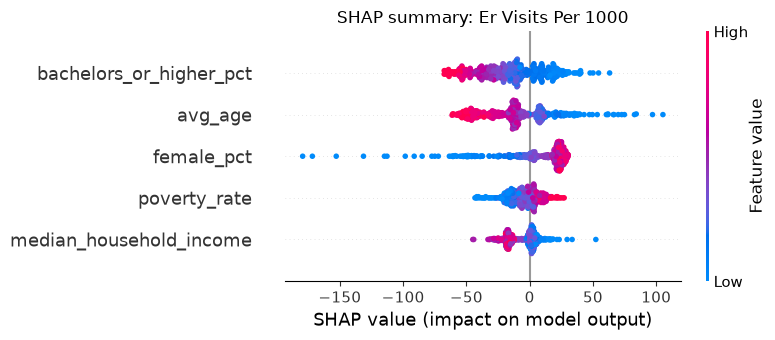

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Top 10 holdout residual outliers: er_visits_per_1000
 fips        county_name  actual  predicted  residual  absolute_residual
25019       MA-Nantucket  775.65 457.589996    318.06             318.06
32023             NV-Nye  258.84 557.419983   -298.58             298.58
37015          NC-Bertie  922.31 652.159973    270.15             270.15
37007           NC-Anson  903.02 648.760010    254.26             254.26
25007           MA-Dukes  724.29 478.839996    245.45             245.45
51730 VA-Petersburg City  885.44 641.429993    244.01             244.01
31149            NE-Rock  342.60 577.950012   -235.35             235.35
37139      NC-Pasquotank  827.11 595.219971    231.89             231.89
51595    VA-Emporia City  863.33 640.280029    223.06             223.06
51620   VA-Franklin City  804.69 592.429993    212.26             212.26

Selected tree model for inpatient_stays_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: inpatient_stays_per_1000


/var/folders/x6/m65zc6011yb_s4d0jj7t31x80000gn/T/ipykernel_82146/2290625379.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


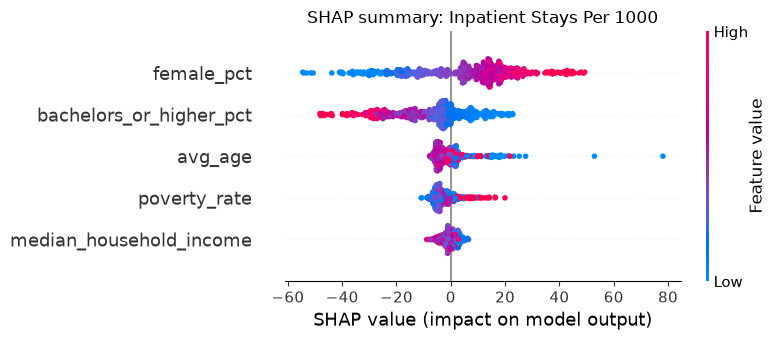

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Top 10 holdout residual outliers: inpatient_stays_per_1000
 fips county_name  actual  predicted  residual  absolute_residual
53001    WA-Adams  144.59 233.860001    -89.28              89.28
53029   WA-Island  131.67 218.149994    -86.47              86.47
19051    IA-Davis  150.22 234.470001    -84.25              84.25
31091   NE-Hooker  178.74 261.709991    -82.97              82.97
31007   NE-Banner  217.39 135.789993     81.60              81.60
55043    WI-Grant  158.12 239.619995    -81.51              81.51
19143  IA-Osceola  154.54 235.100006    -80.56              80.56
31133   NE-Pawnee  165.41 243.690002    -78.28              78.28
31077  NE-Greeley  165.40 243.410004    -78.02              78.02
31037   NE-Colfax  163.65 241.479996    -77.83              77.83

Selected tree model for outpatient_visits_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: outpatient_visits_per_1000
median_household_income    507.984
poverty_rate               435.2

/var/folders/x6/m65zc6011yb_s4d0jj7t31x80000gn/T/ipykernel_82146/2290625379.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


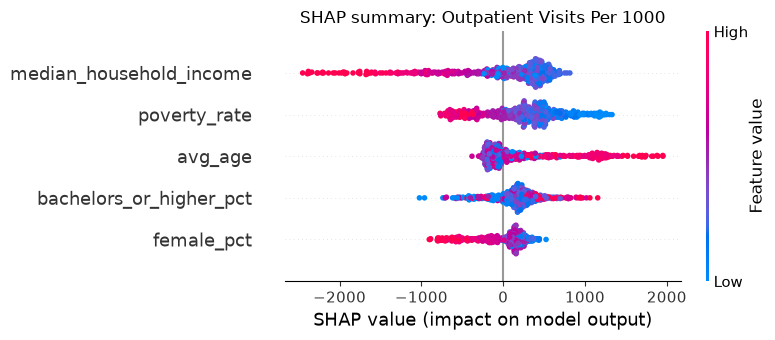


Top 10 holdout residual outliers: outpatient_visits_per_1000
 fips    county_name   actual   predicted  residual  absolute_residual
19167       IA-Sioux 13097.20 6038.680176   7058.52            7058.52
55063   WI-La Crosse 12716.75 5677.830078   7038.93            7038.93
19145        IA-Page 11896.94 5674.600098   6222.33            6222.33
19069    IA-Franklin 12697.81 7292.950195   5404.86            5404.86
25007       MA-Dukes  9610.64 4212.060059   5398.58            5398.58
19033 IA-Cerro Gordo 11118.49 5751.979980   5366.51            5366.51
19081     IA-Hancock 12487.03 7120.899902   5366.12            5366.12
19017      IA-Bremer  9774.46 4607.310059   5167.15            5167.15
19003       IA-Adams 11536.69 6393.680176   5143.01            5143.01
55045       WI-Green 10394.00 5356.729980   5037.27            5037.27


In [26]:
outlier_tables = {}

for target, best_info in best_tree_by_target.items():
    best_model = best_info["model"]
    features = best_info["features"]
    feature_set_name = best_info["feature_set"]

    X_train_shap = analysis_df.iloc[train_idx][features]
    X_test_shap = analysis_df.iloc[test_idx][features]

    background = shap.maskers.Independent(X_train_shap, max_samples=100)

    def predict_from_array(values):
        values_df = pd.DataFrame(values, columns=features)
        return best_model.predict(values_df)

    explainer = shap.Explainer(
        predict_from_array,
        background,
        algorithm="permutation",
        feature_names=features,
    )
    shap_values = explainer(X_test_shap.to_numpy(), max_evals=63)

    mean_abs_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=features,
    ).sort_values(ascending=False)

    print(f"\nSelected tree model for {target}: {feature_set_name}")
    print(f"Mean absolute SHAP attribution: {target}")
    print(mean_abs_shap.round(3).to_string())

    plt.figure(figsize=(9, 5))
    shap.summary_plot(
        shap_values.values,
        X_test_shap,
        feature_names=features,
        show=False,
    )
    plt.title(f"SHAP summary: {target.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

    key = (target, feature_set_name, best_info["model_name"])
    y_test, predictions = holdout_predictions[key]

    outliers = analysis_df.iloc[test_idx][["fips", "county_name"]].copy()
    outliers["actual"] = y_test.to_numpy()
    outliers["predicted"] = predictions
    outliers["residual"] = outliers["actual"] - outliers["predicted"]
    outliers["absolute_residual"] = outliers["residual"].abs()

    outlier_tables[target] = (
        outliers.nlargest(10, "absolute_residual").reset_index(drop=True)
    )

    print(f"\nTop 10 holdout residual outliers: {target}")
    print(outlier_tables[target].round(2).to_string(index=False))

The selected tree-model specification used the socioeconomic indicators, average age, and female share for all three outcomes. Mean absolute SHAP values ranked features by their average contribution magnitude on held-out counties; the values are expressed in the units of each utilization outcome and should only be compared within that outcome. They describe how the fitted models make predictions, not causal effects.

For emergency department visits, educational attainment (24.64 visits per 1,000), average age (24.35), and female share (22.67) had the largest mean absolute SHAP values, followed by poverty (9.84) and household income (9.66). The beeswarm plot suggests that higher educational attainment and average age generally contributed to lower predictions, while higher female share and poverty generally contributed to higher predictions. For inpatient stays, female share had the largest mean absolute attribution (17.21 stays per 1,000), followed by educational attainment (11.58); the remaining features had smaller average contributions. The plot suggests higher female share was generally associated with higher model predictions, while higher educational attainment tended to be associated with lower predictions. For outpatient visits, household income (508.19 visits per 1,000), poverty (434.66), and average age (378.18) ranked highest. The plot suggests higher income and poverty generally contributed to lower predictions, while higher average age generally contributed to higher predictions. These directions are patterns in the fitted models and may be affected by correlations among predictors.

Residuals were calculated as actual minus predicted utilization. Positive residuals indicate underprediction; negative residuals indicate overprediction. For ED visits, the largest underprediction was for Nantucket, Massachusetts (+318 per 1,000), with several North Carolina and Virginia counties also underpredicted. Nye, Nevada (−299), and Rock, Nebraska (−235), were among the largest overpredictions. For inpatient stays, the model overpredicted many of the listed counties, including Adams and Island in Washington and several counties in Iowa, Nebraska, and Wisconsin; Banner, Nebraska, was underpredicted (+82). Outpatient residuals showed substantial underprediction in Iowa and Wisconsin: Sioux, Iowa, was underpredicted by about 7,059 visits per 1,000, and La Crosse, Wisconsin, by about 7,039.

These residuals identify counties where predictions differed most from observed rates; they do not explain the reasons for those differences. The regional patterns may reflect omitted local factors, model limitations, or data issues and should be treated as leads for further investigation, not as causal findings or assessments of care quality. Predictive performance also differed by outcome: ED performance was more promising, inpatient performance did not transfer well to the held-out states, and outpatient cross-validation R² was negative. SHAP results, particularly for outpatient use, should therefore be interpreted as descriptions of model behavior rather than evidence of strong or generalizable predictive relationships.